In [7]:
# Convert DATE column to datetime
df['DATE'] = pd.to_datetime(df['DATE'])

# Define a spike: daily VIX close > threshold (25)
df['spike'] = (df['CLOSE'] > 25).astype(int)

# Aggregate per month (count of spikes)
df['YearMonth'] = df['DATE'].dt.to_period('M')
monthly = df.groupby('YearMonth')['spike'].sum().reset_index()
monthly['month_num'] = monthly['YearMonth'].dt.month
monthly['year'] = monthly['YearMonth'].dt.year

# Calculate average close per month
agg = df.groupby('YearMonth')['CLOSE'].mean().reset_index(name='avg_close')
monthly = monthly.merge(agg, on='YearMonth')

# Prepare predictors and fit models
X = sm.add_constant(monthly[['avg_close', 'month_num']])
y = monthly['spike']

# Fit Poisson regression
poisson = sm.GLM(y, X, family=sm.families.Poisson()).fit()
print(poisson.summary())

# Check overdispersion
dispersion = y.var() / y.mean()
print(f"\nDispersion ratio: {dispersion:.2f}")

# Fit Negative Binomial if overdispersed
if dispersion > 1.5:
    nb = sm.GLM(y, X, family=sm.families.NegativeBinomial()).fit()
    print("\nNegative Binomial Model:")
    print(nb.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                  spike   No. Observations:                  430
Model:                            GLM   Df Residuals:                      427
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1449.4
Date:                Mon, 13 Oct 2025   Deviance:                       2345.8
Time:                        16:44:24   Pearson chi2:                 2.25e+03
No. Iterations:                     7   Pseudo R-squ. (CS):             0.9903
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7300      0.066    -11.006      0.0

/opt/anaconda3/lib/python3.12/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


Model Comparison:
AIC - Poisson: 2904.88
AIC - Negative Binomial: 1231.95

Overdispersion ratio: 12.57

Significant predictors (p < 0.05):

Poisson Model:

Poisson Model Significant Predictors (p < 0.05):
const: coefficient = -0.7300, p-value = 0.0000
avg_close: coefficient = 0.0862, p-value = 0.0000

Negative Binomial Model Significant Predictors (p < 0.05):
const: coefficient = -6.7468, p-value = 0.0000
avg_close: coefficient = 0.3262, p-value = 0.0000


/var/folders/yb/whx8945s5njbtn9r4cvptpd80000gn/T/ipykernel_85259/1121397177.py:41: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{X.columns[idx]}: coefficient = {poisson.params[idx]:.4f}, p-value = {pvalue:.4f}")
/var/folders/yb/whx8945s5njbtn9r4cvptpd80000gn/T/ipykernel_85259/1121397177.py:47: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(f"{X.columns[idx]}: coefficient = {nb.params[idx]:.4f}, p-value = {pvalue:.4f}")


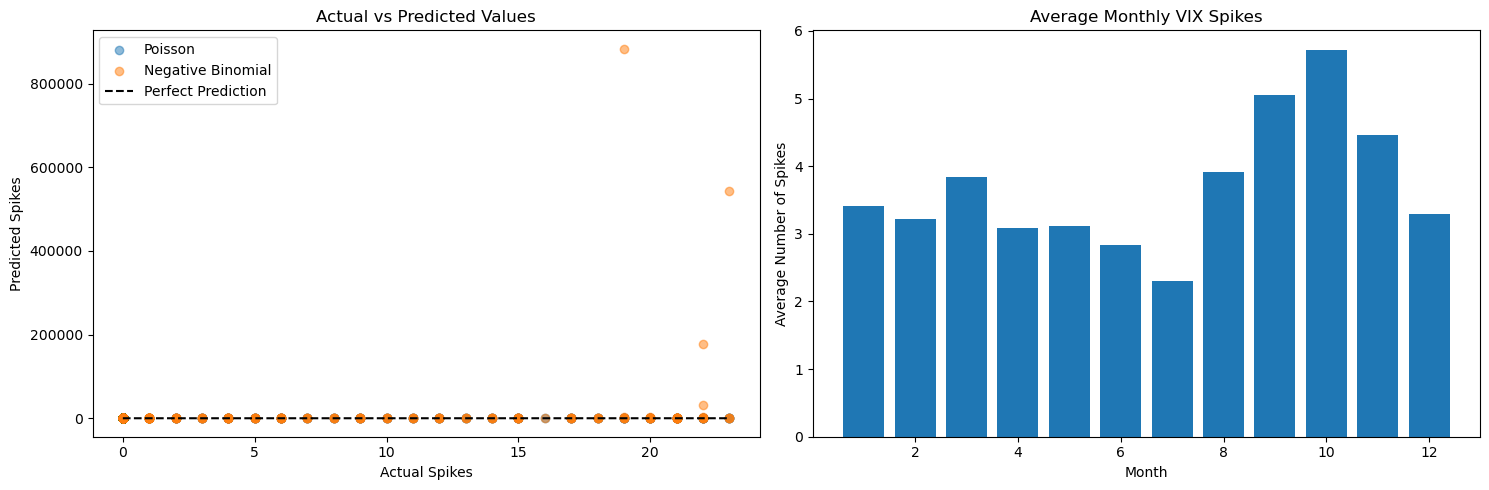

In [11]:
import numpy as np

import matplotlib.pyplot as plt

# Create figure with multiple subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Actual vs Predicted Values
predicted_poisson = poisson.predict(X)
predicted_nb = nb.predict(X)

ax1.scatter(y, predicted_poisson, alpha=0.5, label='Poisson')
ax1.scatter(y, predicted_nb, alpha=0.5, label='Negative Binomial')
ax1.plot([0, y.max()], [0, y.max()], 'k--', label='Perfect Prediction')
ax1.set_xlabel('Actual Spikes')
ax1.set_ylabel('Predicted Spikes')
ax1.legend()
ax1.set_title('Actual vs Predicted Values')

# Plot 2: Monthly Pattern
monthly_avg = monthly.groupby('month_num')['spike'].mean()
ax2.bar(monthly_avg.index, monthly_avg.values)
ax2.set_xlabel('Month')
ax2.set_ylabel('Average Number of Spikes')
ax2.set_title('Average Monthly VIX Spikes')

plt.tight_layout()

# Print model comparison metrics
print("Model Comparison:")
print(f"AIC - Poisson: {poisson.aic:.2f}")
print(f"AIC - Negative Binomial: {nb.aic:.2f}")
print(f"\nOverdispersion ratio: {dispersion:.2f}")
print("\nSignificant predictors (p < 0.05):")
print("\nPoisson Model:")
significant_poisson = poisson.pvalues < 0.05
# Print significant predictors for Poisson model
print("\nPoisson Model Significant Predictors (p < 0.05):")
for idx, pvalue in enumerate(poisson.pvalues):
    if pvalue < 0.05:
        print(f"{X.columns[idx]}: coefficient = {poisson.params[idx]:.4f}, p-value = {pvalue:.4f}")

# Print significant predictors for Negative Binomial model
print("\nNegative Binomial Model Significant Predictors (p < 0.05):")
for idx, pvalue in enumerate(nb.pvalues):
    if pvalue < 0.05:
        print(f"{X.columns[idx]}: coefficient = {nb.params[idx]:.4f}, p-value = {pvalue:.4f}")


Summary Statistics:
Total number of VIX spikes: 1585
Average spikes per month: 3.69
Maximum spikes in one month: 23 (occurred in 1990-10)

Months with highest average number of spikes:
Month 10: 5.72 average spikes
Month 9: 5.06 average spikes
Month 11: 4.46 average spikes


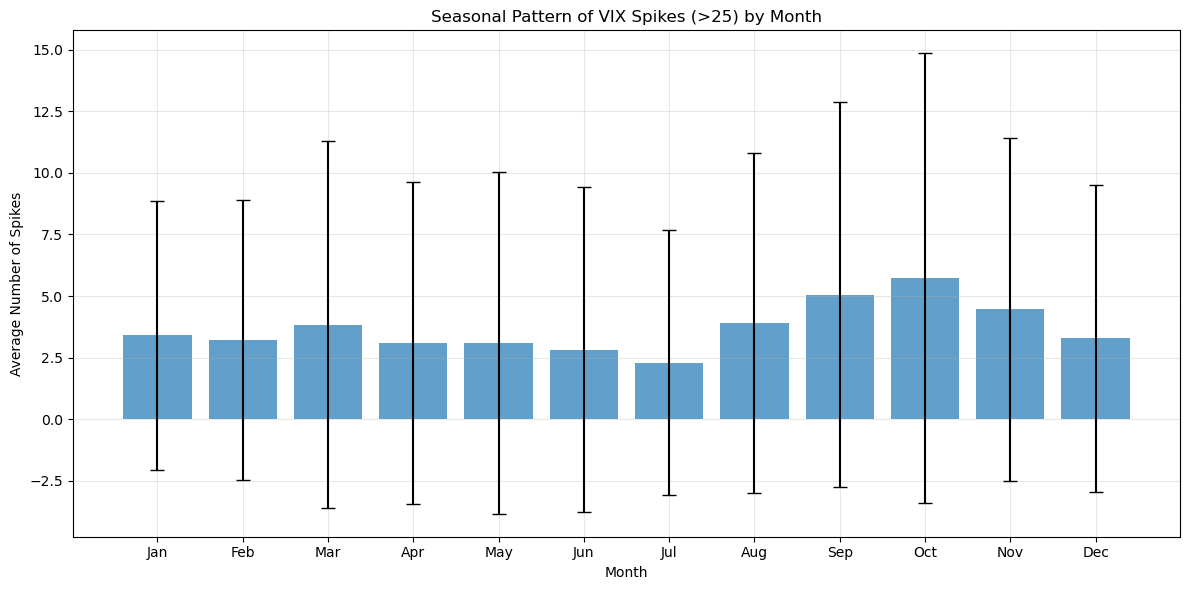

In [12]:
# 1. Create a figure to show seasonal patterns of VIX spikes
plt.figure(figsize=(12, 6))

# Calculate and plot average spikes by month
monthly_pattern = monthly.groupby('month_num')['spike'].agg(['mean', 'std']).reset_index()
plt.bar(monthly_pattern['month_num'], monthly_pattern['mean'], 
    yerr=monthly_pattern['std'], 
    alpha=0.7,
    capsize=5)

# Customize the plot
plt.title('Seasonal Pattern of VIX Spikes (>25) by Month', fontsize=12)
plt.xlabel('Month')
plt.ylabel('Average Number of Spikes')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Calculate some basic statistics
total_spikes = monthly['spike'].sum()
avg_spikes_per_month = monthly['spike'].mean()
max_spikes = monthly['spike'].max()
max_spike_month = monthly.loc[monthly['spike'].idxmax(), 'YearMonth']

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total number of VIX spikes: {total_spikes}")
print(f"Average spikes per month: {avg_spikes_per_month:.2f}")
print(f"Maximum spikes in one month: {max_spikes} (occurred in {max_spike_month})")

# Find months with highest average VIX
print("\nMonths with highest average number of spikes:")
monthly_avg_sorted = monthly_pattern.sort_values('mean', ascending=False)
for _, row in monthly_avg_sorted.head(3).iterrows():
    print(f"Month {int(row['month_num'])}: {row['mean']:.2f} average spikes")

plt.tight_layout()

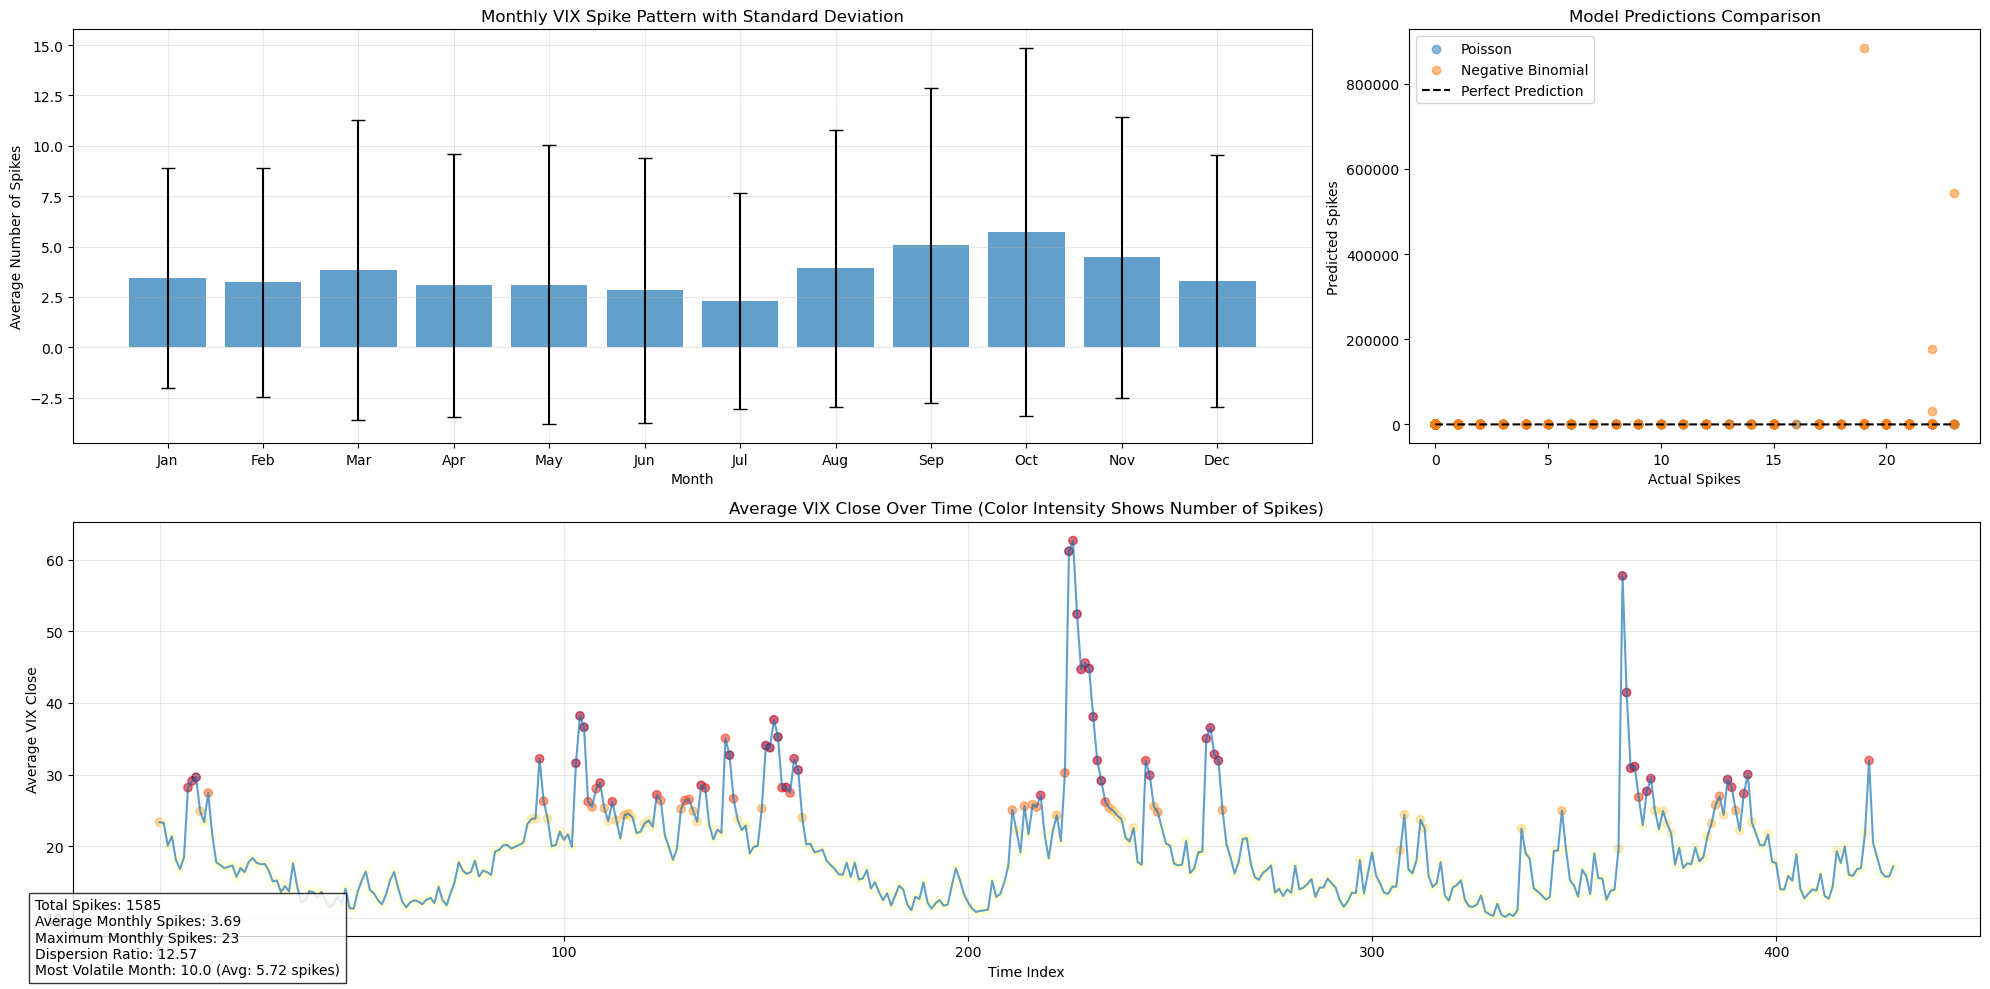

In [ ]:
# Create a comprehensive visualization of VIX spike analysis
fig = plt.figure(figsize=(20, 10))
gs = plt.GridSpec(2, 3, figure=fig)

# 1. Monthly Pattern with Standard Deviation
ax1 = fig.add_subplot(gs[0, :2])
ax1.bar(monthly_pattern['month_num'], monthly_pattern['mean'], 
    yerr=monthly_pattern['std'], 
    alpha=0.7,
    capsize=5)
ax1.set_title('Monthly VIX Spike Pattern with Standard Deviation')
ax1.set_xlabel('Month')
ax1.set_ylabel('Average Number of Spikes')
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
             'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax1.grid(True, alpha=0.3)

# 2. Model Performance Comparison
ax2 = fig.add_subplot(gs[0, 2])
ax2.scatter(y, predicted_poisson, alpha=0.5, label='Poisson')
ax2.scatter(y, predicted_nb, alpha=0.5, label='Negative Binomial')
ax2.plot([0, y.max()], [0, y.max()], 'k--', label='Perfect Prediction')
ax2.set_xlabel('Actual Spikes')
ax2.set_ylabel('Predicted Spikes')
ax2.legend()
ax2.set_title('Model Predictions Comparison')

# 3. Time Series of Average VIX Close
ax3 = fig.add_subplot(gs[1, :])
ax3.plot(range(len(monthly)), monthly['avg_close'], alpha=0.7)
ax3.scatter(range(len(monthly)), monthly['avg_close'], 
       c=monthly['spike'], cmap='YlOrRd', alpha=0.6)
ax3.set_title('Average VIX Close Over Time (Color Intensity Shows Number of Spikes)')
ax3.set_xlabel('Time Index')
ax3.set_ylabel('Average VIX Close')
ax3.grid(True, alpha=0.3)

# Add text box with key statistics
stats_text = (f'Total Spikes: {total_spikes}\n'
         f'Average Monthly Spikes: {avg_spikes_per_month:.2f}\n'
         f'Maximum Monthly Spikes: {max_spikes}\n'
         f'Dispersion Ratio: {dispersion:.2f}\n'
         f'Most Volatile Month: {monthly_avg_sorted.iloc[0]["month_num"]} '
         f'(Avg: {monthly_avg_sorted.iloc[0]["mean"]:.2f} spikes)')

plt.figtext(0.02, 0.02, stats_text, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))
plt.tight_layout()